# Roman Strong Lens Data Challenge — Rung 0
## CNN Two-Stage Pipeline — Classification then Regression

This notebook builds a two-stage pipeline for simulated Roman Space Telescope
images of strong gravitational lenses, using a **ResNet-style Residual CNN**
for both stages:

1. **Stage 1 — Classifier**: a CNN that decides whether an image is a lens or a nonlens.
2. **Stage 2 — Regressor**: a CNN that predicts the **Einstein radius** (θ_e), trained on the ground-truth lens images. The cascade at the end still feeds it whatever Stage 1 flags as a lens — false positives included — so the end-to-end evaluation reflects real-world pipeline behavior.

### Pipeline overview
1. Load the dataset from the `.h5` file
2. Build color images from the three infrared filters (F106, F129, F158)
3. Train the Stage 1 CNN classifier on lens vs. nonlens images
4. Train the Stage 2 CNN regressor on the ground-truth lens images
5. Chain them together: classify first, then regress only what got classified as a lens — regardless of whether that classification is correct
6. Evaluate performance at each stage, and end-to-end


---
## Cell 1: Imports

Everything we need. If anything is missing, install it with `pip install <package>` in your terminal with your conda environment active.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_lupton_rgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Check if a GPU is available — this is what your professor's machine provides
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU name: {torch.cuda.get_device_name(0)}')


Using device: cuda
GPU name: NVIDIA RTX A6000


---
## Cell 2: Load the Dataset

We open the `.h5` file and loop through every lens system, pulling out:
- The three filter images (F106, F129, F158) — our input
- The Einstein radius (theta_e) and SNR — attributes on each lens group
- The `is_strong_lens` flag — an attribute on each individual `lens_*`/`nonlens_*` dataset

**Update the filepath** to match where you downloaded the file.

In [2]:
# ── UPDATE THIS PATH ──────────────────────────────────────────────────────────
h5_filepath = 'roman_data_challenge_rung_0_6040split_v_1_0.h5'
# ─────────────────────────────────────────────────────────────────────────────

f = h5py.File(h5_filepath, 'r')

# The images are stored under a group — find its name
print('Top-level keys in file:', list(f.keys()))

Top-level keys in file: ['images']


In [3]:
images_group = f['images']

In [4]:
print(f'Number of lens systems: {len(images_group.keys())}')

first_key = list(images_group.keys())[0]
first_group = images_group[first_key]
print(f'\nGroup-level attributes for first system: {list(first_group.attrs.keys())}')
print(f'Datasets inside first system: {list(first_group.keys())}')

Number of lens systems: 8096

Group-level attributes for first system: ['deflector_only', 'detector', 'detector_position_x', 'detector_position_y', 'main_halo_mass', 'mu', 'sigma_v', 'substructure', 'theta_e', 'uid', 'z_lens', 'z_source']
Datasets inside first system: ['exposure_00000000_F106', 'exposure_00000000_F129', 'exposure_00000000_F158']


In [5]:
def attr_val(attrs, key):
    """Attrs in this dataset are stored as [value, description] — grab the value."""
    v = attrs[key]
    if isinstance(v, np.ndarray) and v.shape == (2,):
        return v[0]
    return v

def get_bool_attr_val(raw_value):
    """Handles deflector_only whether stored as real bool, numpy bool, string, or bytes."""
    if isinstance(raw_value, (bytes, str)):
        return str(raw_value).strip().lower() in ('true', '1')
    return bool(raw_value)

sample_keys = list(images_group.keys())[:10]
for k in sample_keys:
    grp = images_group[k]
    deflector_only = get_bool_attr_val(attr_val(grp.attrs, 'deflector_only'))
    theta_e = float(attr_val(grp.attrs, 'theta_e'))
    print(f"{k}: deflector_only={deflector_only}, theta_e={theta_e:.4f}")

strong_lens_00000000: deflector_only=True, theta_e=0.6663
strong_lens_00000001: deflector_only=True, theta_e=0.6601
strong_lens_00000002: deflector_only=False, theta_e=0.2892
strong_lens_00000003: deflector_only=False, theta_e=0.6605
strong_lens_00000004: deflector_only=False, theta_e=0.2646
strong_lens_00000005: deflector_only=True, theta_e=0.5819
strong_lens_00000006: deflector_only=True, theta_e=0.6896
strong_lens_00000007: deflector_only=True, theta_e=0.5328
strong_lens_00000008: deflector_only=False, theta_e=1.2763
strong_lens_00000009: deflector_only=True, theta_e=0.7558


---
## Cell 3: Build Images and Labels

Two arrays get built here, both from the same underlying file:

- **Ground-truth lens data** (`all_lens_images`/`all_lens_labels`/`all_lens_snr_values`) — lens images only. This is what the Stage 2 regressor actually trains on (see Cell 10b below).
- **Classifier data** (`images_clf`/`labels_clf`/`theta_e_clf`) — lens *and* nonlens images paired together, used to train Stage 1. `theta_e_clf` is carried along here so the cascade evaluation at the end can look up true radii for whatever the classifier flags as a lens.


In [6]:
# NOTE: these are the ground-truth lens images, used only for the preview
# plot below. The regressor's actual training data (images/labels) gets
# built LATER, from whatever the trained classifier flags as a lens —
# see the "Build the regressor's dataset from the classifier" cell in Stage 2.
all_lens_images = []
all_lens_labels = []
all_lens_rgb_previews = []
all_lens_snr_values = []

def normalize(img):
    mn, mx = img.min(), img.max()
    if mx - mn == 0:
        return np.zeros_like(img, dtype=np.float32)
    return ((img - mn) / (mx - mn)).astype(np.float32)

def get_filter_dataset(group, filter_name):
    matches = [k for k in group.keys() if k.endswith(f'_{filter_name}')]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one key ending in _{filter_name}, found {matches}")
    return group[matches[0]]

for strong_lens_group in images_group.keys():
    lens = images_group[strong_lens_group]

    is_strong_lens = not get_bool_attr_val(attr_val(lens.attrs, 'deflector_only'))
    if not is_strong_lens:
        continue  # this preview/regression set only wants actual lensed systems

    einstein_radius = float(attr_val(lens.attrs, 'theta_e'))

    ds_r = get_filter_dataset(lens, 'F158')
    ds_g = get_filter_dataset(lens, 'F129')
    ds_b = get_filter_dataset(lens, 'F106')

    raw_r = ds_r[:]
    raw_g = ds_g[:]
    raw_b = ds_b[:]

    snr = float(attr_val(ds_b.attrs, 'snr'))  # pulled from the F106 exposure

    norm_r = normalize(raw_r)
    norm_g = normalize(raw_g)
    norm_b = normalize(raw_b)

    stacked = np.stack([norm_r, norm_g, norm_b], axis=0)
    all_lens_images.append(stacked)
    all_lens_labels.append(einstein_radius)
    all_lens_snr_values.append(snr)

    rgb = make_lupton_rgb(image_r=norm_r, image_g=norm_g, image_b=norm_b,
                          stretch=0.2, Q=4)
    all_lens_rgb_previews.append(rgb)

all_lens_images = np.array(all_lens_images, dtype=np.float32)
all_lens_labels = np.array(all_lens_labels, dtype=np.float32)
all_lens_snr_values = np.array(all_lens_snr_values, dtype=np.float32)

print(f'Images array shape : {all_lens_images.shape}')
print(f'Labels array shape : {all_lens_labels.shape}')
print(f'SNR — min: {all_lens_snr_values.min():.2f}, max: {all_lens_snr_values.max():.2f}')

Images array shape : (4835, 3, 91, 91)
Labels array shape : (4835,)
SNR — min: 9.22, max: 737.46


In [7]:
all_nonlens_images = []
all_nonlens_rgb_previews = []
all_nonlens_snr_values = []

for strong_lens_group in images_group.keys():
    lens = images_group[strong_lens_group]

    is_strong_lens = not get_bool_attr_val(attr_val(lens.attrs, 'deflector_only'))
    if is_strong_lens:
        continue  # this set only wants non-lensed (deflector-only) systems

    ds_r = get_filter_dataset(lens, 'F158')
    ds_g = get_filter_dataset(lens, 'F129')
    ds_b = get_filter_dataset(lens, 'F106')

    raw_r = ds_r[:]
    raw_g = ds_g[:]
    raw_b = ds_b[:]

    snr = float(attr_val(ds_b.attrs, 'snr'))  # pulled from the F106 exposure

    norm_r = normalize(raw_r)
    norm_g = normalize(raw_g)
    norm_b = normalize(raw_b)

    stacked = np.stack([norm_r, norm_g, norm_b], axis=0)
    all_nonlens_images.append(stacked)
    all_nonlens_snr_values.append(snr)

    rgb = make_lupton_rgb(image_r=norm_r, image_g=norm_g, image_b=norm_b,
                          stretch=0.2, Q=4)
    all_nonlens_rgb_previews.append(rgb)

all_nonlens_images = np.array(all_nonlens_images, dtype=np.float32)
all_nonlens_snr_values = np.array(all_nonlens_snr_values, dtype=np.float32)

print(f'Images array shape : {all_nonlens_images.shape}')
print(f'SNR — min: {all_nonlens_snr_values.min():.2f}, max: {all_nonlens_snr_values.max():.2f}')

Images array shape : (3261, 3, 91, 91)
SNR — min: 9.47, max: 412.55


In [8]:
images_clf = []
labels_clf = []  # 1.0 = lens, 0.0 = nonlens
theta_e_clf = []  # true radius, carried along for the cascade eval later
snr_clf = []      # true SNR, carried along the same way

for strong_lens_group in images_group.keys():
    group = images_group[strong_lens_group]

    is_strong_lens = not get_bool_attr_val(attr_val(group.attrs, 'deflector_only'))
    einstein_radius = float(attr_val(group.attrs, 'theta_e'))

    ds_r = get_filter_dataset(group, 'F158')
    ds_g = get_filter_dataset(group, 'F129')
    ds_b = get_filter_dataset(group, 'F106')

    raw_r = ds_r[:]
    raw_g = ds_g[:]
    raw_b = ds_b[:]

    snr = float(attr_val(ds_b.attrs, 'snr'))

    norm_r = normalize(raw_r)
    norm_g = normalize(raw_g)
    norm_b = normalize(raw_b)

    stacked = np.stack([norm_r, norm_g, norm_b], axis=0)
    images_clf.append(stacked)

    labels_clf.append(1.0 if is_strong_lens else 0.0)
    theta_e_clf.append(einstein_radius)
    snr_clf.append(snr)

images_clf  = np.array(images_clf, dtype=np.float32)
labels_clf  = np.array(labels_clf, dtype=np.float32)
theta_e_clf = np.array(theta_e_clf, dtype=np.float32)
snr_clf     = np.array(snr_clf, dtype=np.float32)

print(f'Images_clf shape : {images_clf.shape}')
print(f'Labels_clf shape : {labels_clf.shape}')
print(f'Positive (lens) count : {int(labels_clf.sum())} / {len(labels_clf)}')

Images_clf shape : (8096, 3, 91, 91)
Labels_clf shape : (8096,)
Positive (lens) count : 4835 / 8096


---
## Cell 4: Preview the Data

Plot lenses and non-lenses side by side, using the Lupton RGB images so we
can see the color arc structure. Rather than only showing the highest-SNR
examples, the 16 examples in each column are sampled evenly across the full
SNR range (lowest to highest) so you can see what both easy (high-SNR) and
hard (low-SNR) cases actually look like.


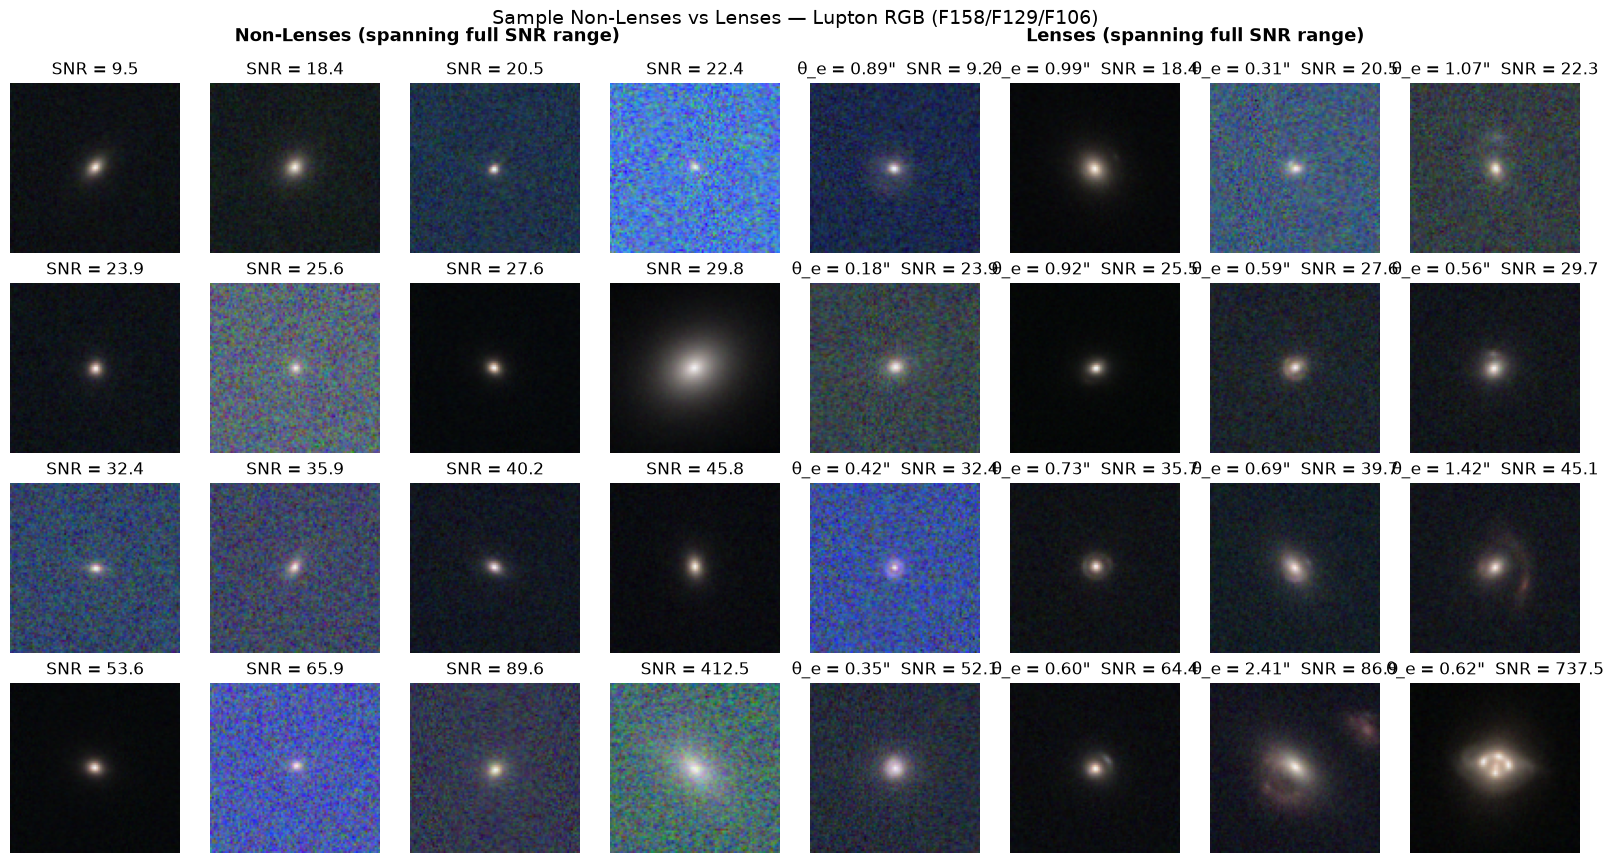

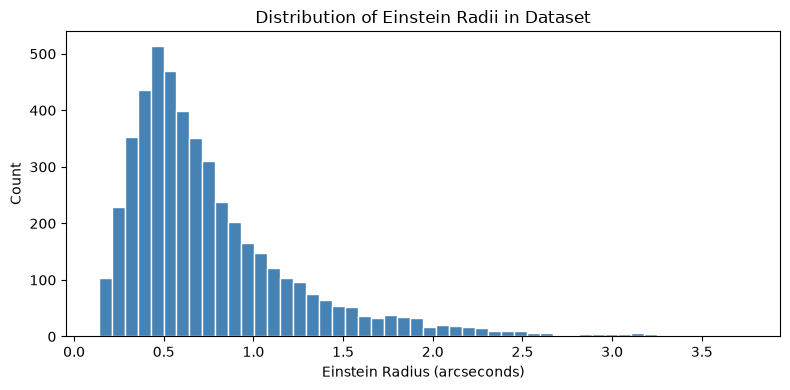

In [9]:
import numpy as np
import matplotlib.pyplot as plt

grid_size = 4
n_show = grid_size ** 2  # 16

def snr_stratified_sample(snr_values, n_show):
    '''Pick n_show indices spanning the full SNR range, low to high,
    instead of only the highest-SNR examples.'''
    order = np.argsort(snr_values)
    pick_positions = np.linspace(0, len(order) - 1, n_show).round().astype(int)
    return order[pick_positions]

lens_sample_idx = snr_stratified_sample(all_lens_snr_values, n_show)
nonlens_sample_idx = snr_stratified_sample(all_nonlens_snr_values, n_show)

lens_imgs = [all_lens_rgb_previews[i] for i in lens_sample_idx]
lens_ers  = [all_lens_labels[i] for i in lens_sample_idx]
lens_snrs = [all_lens_snr_values[i] for i in lens_sample_idx]

nonlens_imgs = [all_nonlens_rgb_previews[i] for i in nonlens_sample_idx]
nonlens_snrs = [all_nonlens_snr_values[i] for i in nonlens_sample_idx]

# --- Plot ---
fig, axes = plt.subplots(grid_size, grid_size * 2, figsize=(16, 8), constrained_layout=True)

for i in range(n_show):
    row, col = i // grid_size, i % grid_size

    # Non-lenses on the left
    ax_nl = axes[row, col]
    ax_nl.imshow(nonlens_imgs[i])
    ax_nl.set_title(f'SNR = {nonlens_snrs[i]:.1f}', fontsize=12)
    ax_nl.axis('off')

    # Lenses on the right
    ax_l = axes[row, col + grid_size]
    ax_l.imshow(lens_imgs[i])
    ax_l.set_title(f'θ_e = {lens_ers[i]:.2f}\"  SNR = {lens_snrs[i]:.1f}', fontsize=12)
    ax_l.axis('off')

# Column-group headers
fig.text(0.27, 1.02, 'Non-Lenses (spanning full SNR range)', ha='center', fontsize=13, fontweight='bold')
fig.text(0.75, 1.02, 'Lenses (spanning full SNR range)', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Sample Non-Lenses vs Lenses — Lupton RGB (F158/F129/F106)', fontsize=14, y=1.06)
plt.show()

# Also plot the distribution of Einstein radii
plt.figure(figsize=(8, 4))
plt.hist(all_lens_labels, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Einstein Radius (arcseconds)')
plt.ylabel('Count')
plt.title('Distribution of Einstein Radii in Dataset')
plt.tight_layout()
plt.show()


---
# STAGE 1 — Classifier: Lens vs. Nonlens

Everything in this section builds and trains `clf_model`, which decides whether an image contains a strong lens. It's trained and evaluated completely independently of the Stage 2 regressor below — it never sees `images`/`labels`.

---
## Cell 5: Data Augmentation (Classifier)

Same dihedral-symmetry trick as the regressor: a lens (or nonlens) image is physically identical whether it's rotated or flipped, so we multiply the classifier's training data by 8× for free.

In [10]:
def augment_dataset(images, labels):
    '''
    Apply 8 dihedral transformations to every image.
    images: (N, 3, H, W)
    labels: (N,)
    Returns augmented arrays of shape (8N, 3, H, W) and (8N,)
    '''
    aug_images, aug_labels = [], []

    for img, label in zip(images, labels):
        for k in range(4):                          # 0, 90, 180, 270 degrees
            rotated = np.rot90(img, k, axes=(1, 2)) # rotate on H, W axes
            aug_images.append(rotated.copy())
            aug_labels.append(label)

            flipped = np.flip(rotated, axis=2).copy()  # horizontal flip
            aug_images.append(flipped)
            aug_labels.append(label)

    return np.array(aug_images, dtype=np.float32), np.array(aug_labels, dtype=np.float32)


images_clf_aug, labels_clf_aug = augment_dataset(images_clf, labels_clf)

print(f'Original classifier dataset  : {images_clf.shape[0]:,} images')
print(f'Augmented classifier dataset : {images_clf_aug.shape[0]:,} images  (8× via dihedral symmetry)')

Original classifier dataset  : 8,096 images
Augmented classifier dataset : 64,768 images  (8× via dihedral symmetry)


---
## Cell 6: PyTorch Dataset and DataLoaders (Classifier)

70% training / 15% validation / 15% test, same split ratios as the regressor. `LensDataset` is generic — it's reused for both stages.

In [11]:
class LensDataset(Dataset):
    '''Simple PyTorch Dataset wrapping our numpy arrays.'''
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


full_dataset_clf = LensDataset(images_clf_aug, labels_clf_aug)
total_clf = len(full_dataset_clf)

n_train_clf = int(0.70 * total_clf)
n_val_clf   = int(0.15 * total_clf)
n_test_clf  = total_clf - n_train_clf - n_val_clf

train_set_clf, val_set_clf, test_set_clf = random_split(
    full_dataset_clf, [n_train_clf, n_val_clf, n_test_clf],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64

train_loader_clf = DataLoader(train_set_clf, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader_clf   = DataLoader(val_set_clf,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_clf  = DataLoader(test_set_clf,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples   : {n_train_clf:,}')
print(f'Validation samples : {n_val_clf:,}')
print(f'Test samples       : {n_test_clf:,}')

Training samples   : 45,337
Validation samples : 9,715
Test samples       : 9,716


---
## Cell 7: Define the Residual CNN

This follows the ResNet-18-inspired pattern from C21 in the More et al. (2024) comparison paper: a stem convolution, followed by residual blocks, then global average pooling and a small FC head. `ResidualBlock` and `ResNetCNN` are defined once here and reused for both the classifier and the regressor — the architecture doesn't need to change between tasks, only the loss function used to train it and how the final number is interpreted (a raw regression value vs. a classification logit).

In [12]:
class ResidualBlock(nn.Module):
    """
    A single residual block: two 3x3 convs with batch norm and ReLU,
    plus a skip connection that adds the block's input back to its output.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)
        return out


class ResNetCNN(nn.Module):
    """
    Residual CNN — used for BOTH stages. The final layer is a single raw
    number (Linear(64, 1), no activation). For the regressor that number
    IS the predicted theta_e. For the classifier, that same number is
    treated as a logit and passed through BCEWithLogitsLoss/sigmoid.

    Architecture:
        Input  : (batch, 3, 73, 73)
        Stem   : Conv(3->16) + BN + ReLU                  -> (batch, 16, 73, 73)
        Stage 1: ResidualBlock(16->32,  stride=2) x2       -> (batch, 32, 36, 36)
        Stage 2: ResidualBlock(32->64,  stride=2) x2       -> (batch, 64, 18, 18)
        Stage 3: ResidualBlock(64->128, stride=2) x2       -> (batch, 128, 9, 9)
        Stage 4: ResidualBlock(128->256,stride=2) x2       -> (batch, 256, 5, 5)
        Pool   : AdaptiveAvgPool2d(1)                      -> (batch, 256, 1, 1)
        FC head: 256 -> 64 -> 1
    """
    def __init__(self):
        super(ResNetCNN, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(16, 32, stride=2),
            ResidualBlock(32, 32, stride=1)
        )
        self.stage2 = nn.Sequential(
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64, stride=1)
        )
        self.stage3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128, stride=1)
        )
        self.stage4 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=1)
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.global_pool(x)
        x = self.fc_head(x)
        return x.squeeze(1)


# ── Instantiate the Stage 1 classifier model ───────────────────────────────
clf_model = ResNetCNN().to(device)
print(clf_model)

total_params = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')


ResNetCNN(
  (stem): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(16, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 3

---
## Cell 8: Training Setup (Classifier)

**Loss:** `BCEWithLogitsLoss` (sigmoid + binary cross-entropy, numerically stable) since this is a binary lens/nonlens decision, not a regression.
**Optimizer/scheduler/early stopping:** same setup style as the regressor. `EarlyStopping` is defined once here and reused for both stages.

In [13]:
LEARNING_RATE_CLF = 3e-4
NUM_EPOCHS_CLF    = 150

criterion_clf = nn.BCEWithLogitsLoss()
optimizer_clf = optim.Adam(clf_model.parameters(), lr=LEARNING_RATE_CLF)

scheduler_clf = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_clf, mode='min', factor=0.5, patience=9
)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


early_stopper_clf = EarlyStopping(patience=18, min_delta=1e-5)

print(f'Loss      : BCEWithLogitsLoss')
print(f'Optimizer : Adam  (lr={LEARNING_RATE_CLF})')
print(f'Max Epochs: {NUM_EPOCHS_CLF}')


Loss      : BCEWithLogitsLoss
Optimizer : Adam  (lr=0.0003)
Max Epochs: 150


---
## Cell 9: Training Loop (Classifier)

Trains `clf_model` and saves the best weights (by validation loss) to `best_clf_model.pt`. Run this before anything downstream that depends on `clf_model` being trained.

In [15]:
train_losses_clf = []
val_losses_clf   = []
best_val_loss_clf = float('inf')

early_stopper_clf.best_loss = float('inf')
early_stopper_clf.counter = 0
early_stopper_clf.should_stop = False

for epoch in range(NUM_EPOCHS_CLF):
    clf_model.train()
    running_train_loss = 0.0
    running_train_correct = 0

    for images_batch, labels_batch in train_loader_clf:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        optimizer_clf.zero_grad()
        logits = clf_model(images_batch)
        loss = criterion_clf(logits, labels_batch)
        loss.backward()
        optimizer_clf.step()

        running_train_loss += loss.item() * len(images_batch)
        preds = (torch.sigmoid(logits) > 0.5).float()
        running_train_correct += (preds == labels_batch).sum().item()

    avg_train_loss = running_train_loss / n_train_clf
    avg_train_acc  = running_train_correct / n_train_clf

    clf_model.eval()
    running_val_loss = 0.0
    running_val_correct = 0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader_clf:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)
            logits = clf_model(images_batch)
            loss = criterion_clf(logits, labels_batch)
            running_val_loss += loss.item() * len(images_batch)
            preds = (torch.sigmoid(logits) > 0.5).float()
            running_val_correct += (preds == labels_batch).sum().item()

    avg_val_loss = running_val_loss / n_val_clf
    avg_val_acc  = running_val_correct / n_val_clf

    train_losses_clf.append(avg_train_loss)
    val_losses_clf.append(avg_val_loss)

    if avg_val_loss < best_val_loss_clf:
        best_val_loss_clf = avg_val_loss
        torch.save(clf_model.state_dict(), 'best_clf_model.pt')

    old_lr = optimizer_clf.param_groups[0]['lr']
    scheduler_clf.step(avg_val_loss)
    new_lr = optimizer_clf.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f'  → Learning rate reduced: {old_lr:.2e} → {new_lr:.2e}')

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{NUM_EPOCHS_CLF} — '
              f'Train Loss: {avg_train_loss:.4f}  Train Acc: {avg_train_acc:.4f}  |  '
              f'Val Loss: {avg_val_loss:.4f}  Val Acc: {avg_val_acc:.4f}  |  '
              f'EarlyStop counter: {early_stopper_clf.counter}/{early_stopper_clf.patience}')

    if early_stopper_clf.step(avg_val_loss):
        print(f'\nEarly stopping triggered at epoch {epoch+1}.')
        print(f'Best validation loss: {early_stopper_clf.best_loss:.6f}')
        break

print(f'\nBest validation loss: {best_val_loss_clf:.6f}')


Epoch   5/150 — Train Loss: 0.0523  Train Acc: 0.9824  |  Val Loss: 0.0429  Val Acc: 0.9866  |  EarlyStop counter: 0/18
Epoch  10/150 — Train Loss: 0.0265  Train Acc: 0.9912  |  Val Loss: 0.0831  Val Acc: 0.9793  |  EarlyStop counter: 4/18
Epoch  15/150 — Train Loss: 0.0181  Train Acc: 0.9940  |  Val Loss: 0.0525  Val Acc: 0.9849  |  EarlyStop counter: 1/18
Epoch  20/150 — Train Loss: 0.0127  Train Acc: 0.9959  |  Val Loss: 0.0661  Val Acc: 0.9870  |  EarlyStop counter: 6/18
Epoch  25/150 — Train Loss: 0.0115  Train Acc: 0.9960  |  Val Loss: 0.0628  Val Acc: 0.9849  |  EarlyStop counter: 1/18
Epoch  30/150 — Train Loss: 0.0073  Train Acc: 0.9974  |  Val Loss: 0.0516  Val Acc: 0.9889  |  EarlyStop counter: 6/18
  → Learning rate reduced: 3.00e-04 → 1.50e-04
Epoch  35/150 — Train Loss: 0.0029  Train Acc: 0.9991  |  Val Loss: 0.0610  Val Acc: 0.9899  |  EarlyStop counter: 11/18
Epoch  40/150 — Train Loss: 0.0009  Train Acc: 0.9998  |  Val Loss: 0.0914  Val Acc: 0.9885  |  EarlyStop counte

---
## Cell 10: Evaluate Stage 1 on its Test Set

In [16]:
clf_model.load_state_dict(torch.load('best_clf_model.pt', map_location=device))
clf_model.eval()

all_preds_clf  = []
all_probs_clf  = []
all_labels_clf = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader_clf:
        images_batch = images_batch.to(device)
        logits = clf_model(images_batch)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds_clf.extend(preds.cpu().numpy())
        all_probs_clf.extend(probs.cpu().numpy())
        all_labels_clf.extend(labels_batch.numpy())

all_preds_clf  = np.array(all_preds_clf)
all_probs_clf  = np.array(all_probs_clf)
all_labels_clf = np.array(all_labels_clf)

test_acc  = accuracy_score(all_labels_clf, all_preds_clf)
test_prec = precision_score(all_labels_clf, all_preds_clf)
test_rec  = recall_score(all_labels_clf, all_preds_clf)
test_f1   = f1_score(all_labels_clf, all_preds_clf)
cm        = confusion_matrix(all_labels_clf, all_preds_clf)

print('── Stage 1 Test Set Results ──────────────────────')
print(f'Accuracy  : {test_acc:.4f}')
print(f'Precision : {test_prec:.4f}')
print(f'Recall    : {test_rec:.4f}')
print(f'F1        : {test_f1:.4f}')
print('──────────────────────────────────────────────────')
print('Confusion matrix (rows=true, cols=pred), order = [nonlens, lens]:')
print(cm)

── Stage 1 Test Set Results ──────────────────────
Accuracy  : 0.9927
Precision : 0.9958
Recall    : 0.9918
F1        : 0.9938
──────────────────────────────────────────────────
Confusion matrix (rows=true, cols=pred), order = [nonlens, lens]:
[[3938   24]
 [  47 5707]]


---
# STAGE 2 — Regressor: Einstein Radius

Everything in this section builds and trains `model`, which predicts θ_e. It trains on the ground-truth lens images (`all_lens_*`, built in Cell 3) — not on whatever the classifier happens to flag. This keeps Stage 2's training signal clean, since we know these labels are correct. It's evaluated in isolation first (Cells 17–19 below), then chained to Stage 1 in the Two-Stage Cascade section, where it does see whatever the classifier flags as a lens — false positives included.


---
## Cell 10b: Set the Regressor's Training Data

Point `images`/`labels`/`rgb_previews`/`snr_values` at the ground-truth lens arrays built in Cell 3. Everything below in Stage 2 (augmentation, split, training) just uses these names generically, so nothing else needs to change.


In [17]:
images = all_lens_images
labels = all_lens_labels
rgb_previews = all_lens_rgb_previews
snr_values = all_lens_snr_values

print(f'Regressor training set (ground-truth lenses): {images.shape}')


Regressor training set (ground-truth lenses): (4835, 3, 91, 91)


---
## Cell 11: Data Augmentation (Regressor)

As recommended by Schaefer et al. (2018), we exploit the dihedral symmetry of gravitational lenses: rotations and a flip give 8 free variants of every training image. Reuses `augment_dataset` defined in Stage 1 above.

In [18]:
images_aug, labels_aug = augment_dataset(images, labels)

print(f'Original dataset  : {images.shape[0]:,} images')
print(f'Augmented dataset : {images_aug.shape[0]:,} images  (8× via dihedral symmetry)')

Original dataset  : 4,835 images
Augmented dataset : 38,680 images  (8× via dihedral symmetry)


---
## Cell 12: PyTorch Dataset and DataLoaders (Regressor)

70% training / 15% validation / 15% test. Reuses the `LensDataset` class defined in Stage 1.

In [19]:
full_dataset = LensDataset(images_aug, labels_aug)
total = len(full_dataset)

n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)   # reproducible split
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples   : {n_train:,}')
print(f'Validation samples : {n_val:,}')
print(f'Test samples       : {n_test:,}')

Training samples   : 27,076
Validation samples : 5,802
Test samples       : 5,802


---
## Cell 13: Instantiate the Regressor

Reuses the same `ResNetCNN` class defined in Stage 1 — a fresh, separately-trained instance.

In [20]:
model = ResNetCNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')


ResNetCNN(
  (stem): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(16, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 3

---
## Cell 14: Training Setup (Regressor)

**Loss:** Huber loss — behaves like MSE for small errors, like MAE for large ones, so a few huge outliers can't dominate the gradient.
**Optimizer:** Adam, lr `3e-4`. **Scheduler:** halves the LR after 9 stagnant epochs. **Early stopping:** stops after 18 stagnant epochs. Reuses the `EarlyStopping` class defined in Stage 1.

In [21]:
LEARNING_RATE = 3e-4
NUM_EPOCHS    = 150

HUBER_DELTA = 0.1

criterion = nn.HuberLoss(delta=HUBER_DELTA)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=9
)

early_stopper = EarlyStopping(patience=18, min_delta=1e-5)

print(f'Loss      : Huber (delta={HUBER_DELTA})')
print(f'Optimizer : Adam  (lr={LEARNING_RATE})')
print(f'Max Epochs: {NUM_EPOCHS}  (early stopping patience={early_stopper.patience}, '
      f'scheduler patience={scheduler.patience})')
print(f'Batch     : {BATCH_SIZE}')


Loss      : Huber (delta=0.1)
Optimizer : Adam  (lr=0.0003)
Max Epochs: 150  (early stopping patience=18, scheduler patience=9)
Batch     : 64


---
## Cell 15: Training Loop (Regressor)

Trains `model` and saves the best weights (by validation loss) to `best_model.pt`. This must run before the cascade cells at the end of the notebook — they load these saved weights rather than retraining.

In [22]:
train_losses = []
val_losses   = []
best_val_loss = float('inf')

early_stopper.best_loss = float('inf')
early_stopper.counter = 0
early_stopper.should_stop = False

for epoch in range(NUM_EPOCHS):

    model.train()
    running_train_loss = 0.0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        predictions = model(images_batch)
        loss = criterion(predictions, labels_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * len(images_batch)

    avg_train_loss = running_train_loss / n_train

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)
            predictions  = model(images_batch)
            loss = criterion(predictions, labels_batch)
            running_val_loss += loss.item() * len(images_batch)

    avg_val_loss = running_val_loss / n_val

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pt')

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f'  → Learning rate reduced: {old_lr:.2e} → {new_lr:.2e}')

    if (epoch + 1) % 5 == 0:
        train_rmse = np.sqrt(avg_train_loss)
        val_rmse   = np.sqrt(avg_val_loss)
        print(f'Epoch {epoch+1:3d}/{NUM_EPOCHS} — '
              f'Train RMSE: {train_rmse:.4f}"  |  '
              f'Val RMSE: {val_rmse:.4f}"  |  '
              f'EarlyStop counter: {early_stopper.counter}/{early_stopper.patience}')

    if early_stopper.step(avg_val_loss):
        print(f'\nEarly stopping triggered at epoch {epoch+1} '
              f'(no improvement for {early_stopper.patience} epochs).')
        print(f'Best validation loss (MSE): {early_stopper.best_loss:.6f}')
        break

print(f'\nBest validation loss (MSE): {best_val_loss:.6f}')
print(f'Best validation RMSE      : {np.sqrt(best_val_loss):.4f} arcseconds')


Epoch   5/150 — Train RMSE: 0.0865"  |  Val RMSE: 0.0758"  |  EarlyStop counter: 0/18
Epoch  10/150 — Train RMSE: 0.0739"  |  Val RMSE: 0.0654"  |  EarlyStop counter: 0/18
Epoch  15/150 — Train RMSE: 0.0671"  |  Val RMSE: 0.0603"  |  EarlyStop counter: 2/18
Epoch  20/150 — Train RMSE: 0.0648"  |  Val RMSE: 0.0632"  |  EarlyStop counter: 2/18
Epoch  25/150 — Train RMSE: 0.0625"  |  Val RMSE: 0.0627"  |  EarlyStop counter: 7/18
Epoch  30/150 — Train RMSE: 0.0597"  |  Val RMSE: 0.0642"  |  EarlyStop counter: 3/18
Epoch  35/150 — Train RMSE: 0.0580"  |  Val RMSE: 0.0605"  |  EarlyStop counter: 0/18
Epoch  40/150 — Train RMSE: 0.0577"  |  Val RMSE: 0.0649"  |  EarlyStop counter: 5/18
Epoch  45/150 — Train RMSE: 0.0554"  |  Val RMSE: 0.0590"  |  EarlyStop counter: 2/18
Epoch  50/150 — Train RMSE: 0.0549"  |  Val RMSE: 0.0570"  |  EarlyStop counter: 1/18
Epoch  55/150 — Train RMSE: 0.0540"  |  Val RMSE: 0.0585"  |  EarlyStop counter: 0/18
Epoch  60/150 — Train RMSE: 0.0529"  |  Val RMSE: 0.05

---
## Cell 16: Plot Training History (Regressor)

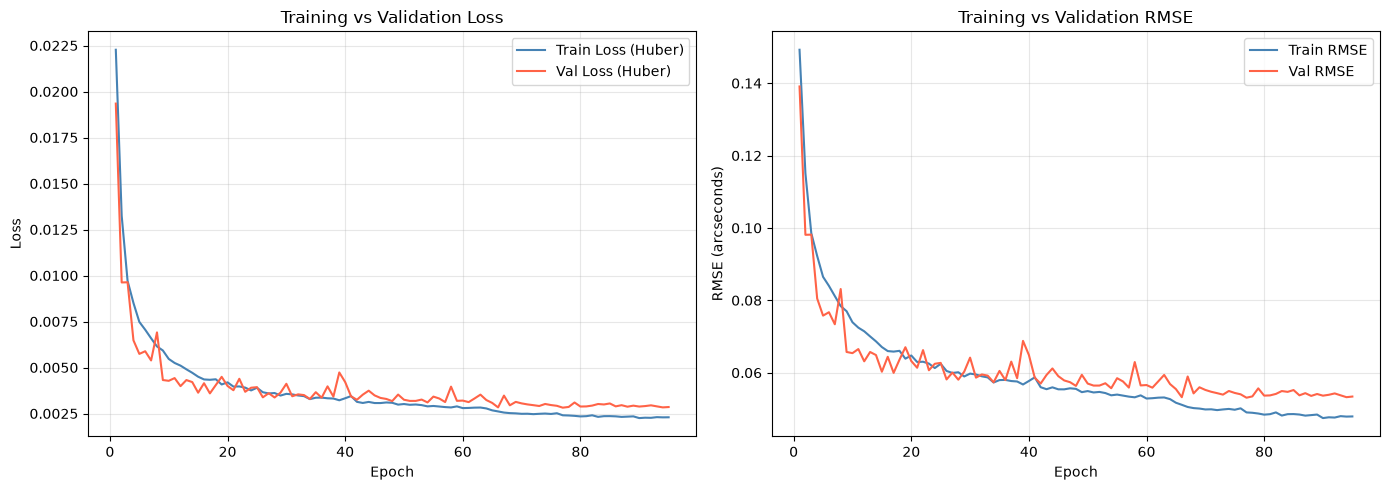

In [23]:
epochs = range(1, epoch+2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, label='Train Loss (Huber)', color='steelblue')
axes[0].plot(epochs, val_losses,   label='Val Loss (Huber)',   color='tomato')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, np.sqrt(train_losses), label='Train RMSE', color='steelblue')
axes[1].plot(epochs, np.sqrt(val_losses),   label='Val RMSE',   color='tomato')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE (arcseconds)')
axes[1].set_title('Training vs Validation RMSE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Cell 17: Evaluate Stage 2 on its Test Set

In [24]:
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        preds = model(images_batch)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_mse  = np.mean((all_preds - all_labels) ** 2)
test_rmse = np.sqrt(test_mse)
test_mae  = np.mean(np.abs(all_preds - all_labels))
test_r2   = r2_score(all_labels, all_preds)

print('── Stage 2 Test Set Results ──────────────────────')
print(f'RMSE : {test_rmse:.4f} arcseconds')
print(f'MAE  : {test_mae:.4f} arcseconds')
print(f'R²   : {test_r2:.4f}')
print('──────────────────────────────────────────────────')
print()
print('Interpretation:')
print(f'  On average, predictions are off by ~{test_rmse:.3f} arcseconds')
print(f'  R² of {test_r2:.3f} means the model explains {test_r2*100:.1f}% of the variance in Einstein radius')

── Stage 2 Test Set Results ──────────────────────
RMSE : 0.0993 arcseconds
MAE  : 0.0546 arcseconds
R²   : 0.9621
──────────────────────────────────────────────────

Interpretation:
  On average, predictions are off by ~0.099 arcseconds
  R² of 0.962 means the model explains 96.2% of the variance in Einstein radius


---
## Cell 18: Visualize Predictions

Predicted vs true scatter, and residuals — how good is the regressor's own test-set performance? This looks only at Stage 2 in isolation, using the test split from its own training data (the ground-truth lenses). It does NOT yet account for the classifier's mistakes — that end-to-end view comes later, in the Two-Stage Cascade section.


findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: F

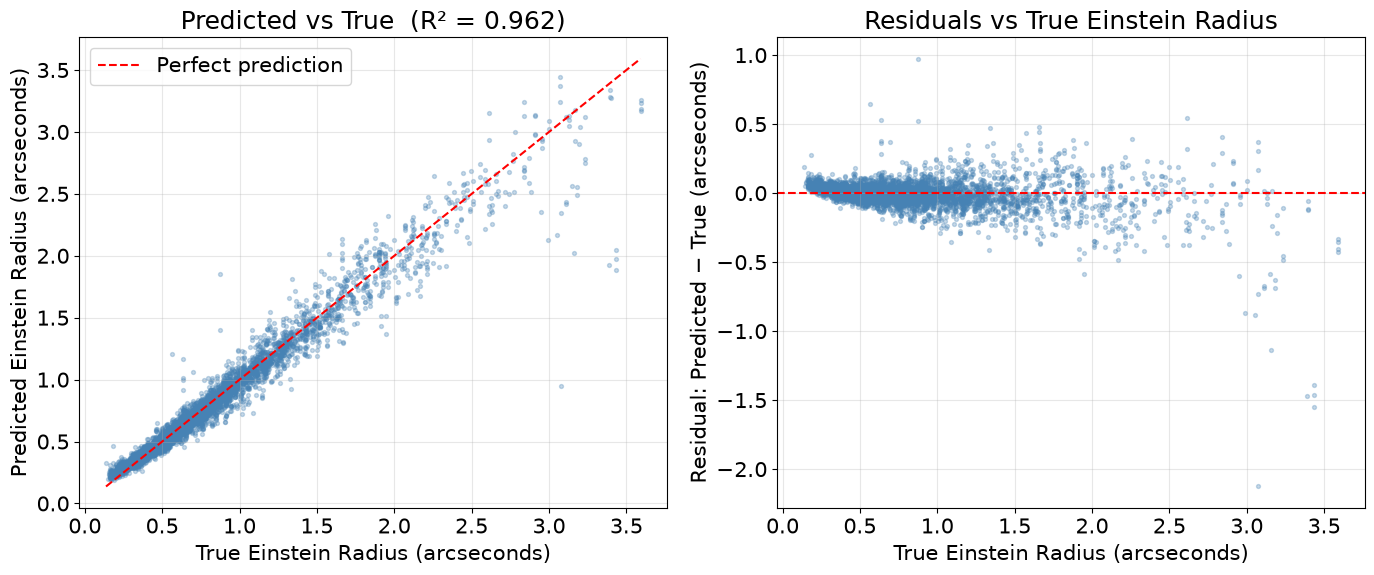

findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: F

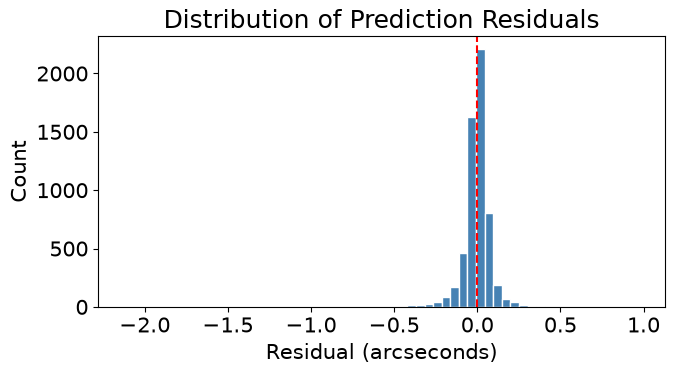

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(all_labels, all_preds, alpha=0.3, s=8, color='steelblue')
lims = [all_labels.min(), all_labels.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('True Einstein Radius (arcseconds)')
axes[0].set_ylabel('Predicted Einstein Radius (arcseconds)')
axes[0].set_title(f'Predicted vs True  (R² = {test_r2:.3f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = all_preds - all_labels
axes[1].scatter(all_labels, residuals, alpha=0.3, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('True Einstein Radius (arcseconds)')
axes[1].set_ylabel('Residual: Predicted − True (arcseconds)')
axes[1].set_title('Residuals vs True Einstein Radius')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (arcseconds)')
plt.ylabel('Count')
plt.title('Distribution of Prediction Residuals')
plt.tight_layout()
plt.show()

findfont: Font family 'Calibri' not found.
findfont: Font family ['Calibri'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family '

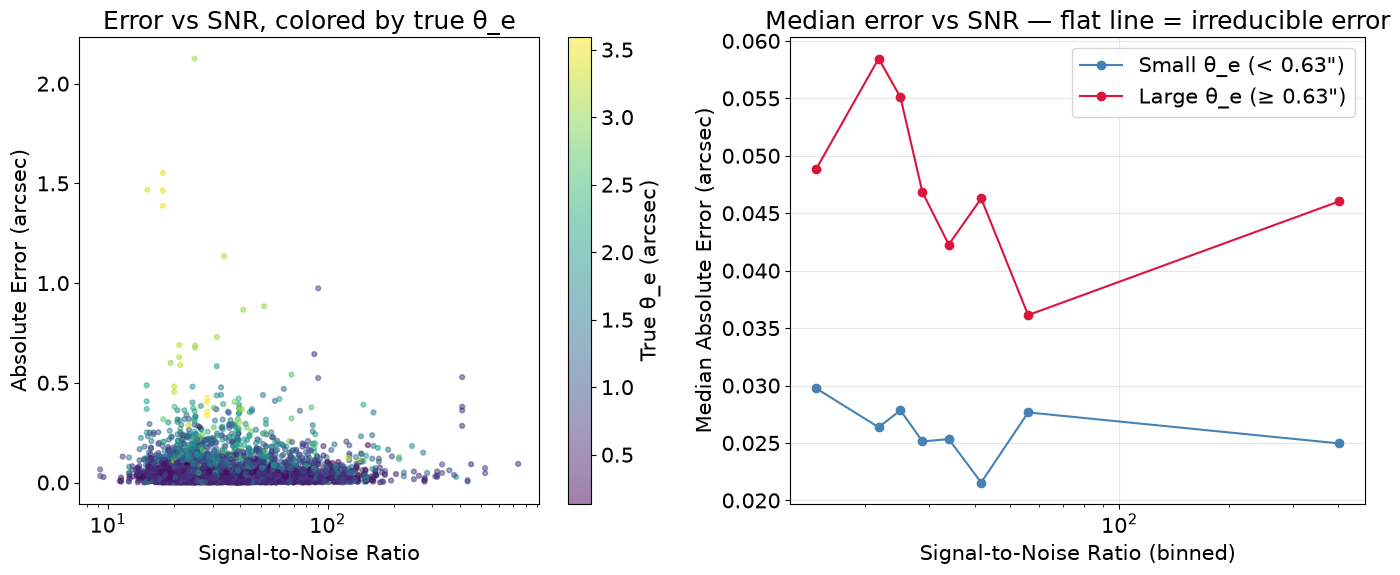

In [27]:
# ── Error vs SNR ─────────────────────────────────────────────────────────────

test_indices = test_set.indices
orig_indices_full = np.array([idx // 8 for idx in test_indices])

test_snr = snr_values[orig_indices_full]
abs_error = np.abs(all_preds - all_labels)

theta_e_median = np.median(all_labels)
is_large_theta_e = all_labels >= theta_e_median

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc = axes[0].scatter(test_snr, abs_error, c=all_labels, cmap='viridis',
                      alpha=0.5, s=12)
axes[0].set_xlabel('Signal-to-Noise Ratio')
axes[0].set_ylabel('Absolute Error (arcsec)')
axes[0].set_xscale('log')
axes[0].set_title('Error vs SNR, colored by true θ_e')
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label('True θ_e (arcsec)')

n_bins = 8
snr_bin_edges = np.percentile(test_snr, np.linspace(0, 100, n_bins + 1))
snr_bin_centers = 0.5 * (snr_bin_edges[:-1] + snr_bin_edges[1:])

for mask, label, color in [(~is_large_theta_e, f'Small θ_e (< {theta_e_median:.2f}")', 'steelblue'),
                             (is_large_theta_e, f'Large θ_e (≥ {theta_e_median:.2f}")', 'crimson')]:
    binned_median_error = []
    for i in range(n_bins):
        in_bin = mask & (test_snr >= snr_bin_edges[i]) & (test_snr < snr_bin_edges[i + 1])
        if in_bin.sum() > 0:
            binned_median_error.append(np.median(abs_error[in_bin]))
        else:
            binned_median_error.append(np.nan)
    axes[1].plot(snr_bin_centers, binned_median_error, 'o-', color=color, label=label)

from matplotlib.ticker import LogLocator, NullFormatter

axes[1].set_xlabel('Signal-to-Noise Ratio (binned)')
axes[1].set_ylabel('Median Absolute Error (arcsec)')
axes[1].set_xscale('log')
axes[1].set_title('Median error vs SNR — flat line = irreducible error')

# limit to major ticks only, and space them out
axes[1].xaxis.set_minor_formatter(NullFormatter())  # hide minor tick labels
axes[1].xaxis.set_major_locator(LogLocator(base=10, numticks=6))
axes[1].tick_params(axis='x', labelsize=15, rotation=0)

axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
def get_worst_predictions(all_preds, all_labels, orig_indices_full, n_worst=25):
    '''
    Returns a DataFrame of the n_worst predictions by absolute error, with
    columns for prediction, truth, error, and the original lens index.
    '''
    import pandas as pd
    abs_errors = np.abs(all_preds - all_labels)
    worst_order = np.argsort(abs_errors)[::-1][:n_worst]

    df = pd.DataFrame({
        'test_pos':       worst_order,
        'orig_idx':       orig_indices_full[worst_order],
        'pred':           all_preds[worst_order],
        'truth':          all_labels[worst_order],
        'abs_error':      abs_errors[worst_order],
        'signed_error':   (all_preds - all_labels)[worst_order],
    })
    return df


def attach_physical_properties(worst_df, labels, snr_values=None):
    '''Joins metadata onto the worst-prediction DataFrame using orig_idx.'''
    idx = worst_df['orig_idx'].values

    worst_df['theta_e_true'] = labels[idx]

    if snr_values is not None:
        worst_df['snr'] = snr_values[idx]

    worst_df['pct_error'] = 100 * worst_df['abs_error'] / worst_df['truth']

    return worst_df


def print_worst_summary(worst_df, n_show=25):
    '''Pretty-print the worst predictions table for quick eyeballing.'''
    cols_priority = ['orig_idx', 'truth', 'pred', 'abs_error', 'pct_error',
                      'theta_e_true', 'snr']
    cols = [c for c in cols_priority if c in worst_df.columns]
    cols += [c for c in worst_df.columns if c not in cols and c not in
             ('test_pos', 'signed_error')]

    print(f'\\n── Worst {n_show} Predictions by Absolute Error ───────────────────────')
    print(worst_df[cols].head(n_show).to_string(index=False, float_format='%.4f'))

    if 'theta_e_true' in worst_df.columns:
        print(f'\\nWorst-{n_show} theta_e stats:')
        print(f"  mean={worst_df['theta_e_true'].head(n_show).mean():.3f}  "
              f"median={worst_df['theta_e_true'].head(n_show).median():.3f}  "
              f"min={worst_df['theta_e_true'].head(n_show).min():.3f}  "
              f"max={worst_df['theta_e_true'].head(n_show).max():.3f}")


def plot_worst_images(worst_df, rgb_previews, n_show=12, cols=3, panel_size=5):
    '''Displays the combined Lupton RGB image for the worst-N predictions,
    one panel per lens, arranged in a grid.'''
    n_show = min(n_show, len(worst_df))
    rows = int(np.ceil(n_show / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(panel_size * cols, panel_size * rows))
    axes = np.atleast_1d(axes).flatten()

    for i, (_, r) in enumerate(worst_df.head(n_show).iterrows()):
        orig_idx = int(r['orig_idx'])
        combined = rgb_previews[orig_idx]

        snr_str = f"  snr={r['snr']:.1f}" if 'snr' in worst_df.columns else ''
        pct_err_str = f"  err={r['pct_error']:.1f}%" if 'pct_error' in worst_df.columns else ''

        ax = axes[i]
        ax.imshow(combined)
        ax.axis('off')

        title = f'pred={r["pred"]:.3f}"  true={r["truth"]:.3f}"{pct_err_str}{snr_str}'
        ax.set_title(title, fontsize=10)

    for ax in axes[n_show:]:
        ax.axis('off')

    plt.suptitle('Worst Predictions — Combined Lupton RGB (F158/F129/F106)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: F

\n── Worst 25 Predictions by Absolute Error ───────────────────────
 orig_idx  truth   pred  abs_error  pct_error  theta_e_true      snr
      154 3.0750 0.9490     2.1260    69.1375        3.0750  24.7946
     1763 3.4351 1.8826     1.5525    45.1964        3.4351  17.7692
     2351 3.3899 1.9222     1.4677    43.2963        3.3899  15.0993
     1763 3.4351 1.9706     1.4645    42.6337        3.4351  17.7692
     1763 3.4351 2.0479     1.3872    40.3843        3.4351  17.7692
     3064 3.1586 2.0233     1.1353    35.9429        3.1586  33.7838
     2179 0.8762 1.8501     0.9739   111.1452        0.8762  90.5985
     3922 3.0512 2.1674     0.8838    28.9645        3.0512  51.3674
     1135 2.9916 2.1258     0.8658    28.9420        2.9916  41.2971
      628 3.0754 2.3454     0.7300    23.7365        3.0754  31.3379
     1488 3.1811 2.4916     0.6895    21.6742        3.1811  21.1028
     4099 3.1089 2.4209     0.6879    22.1280        3.1089  24.9321
     4099 3.1089 2.4326     0.6763 

findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: F

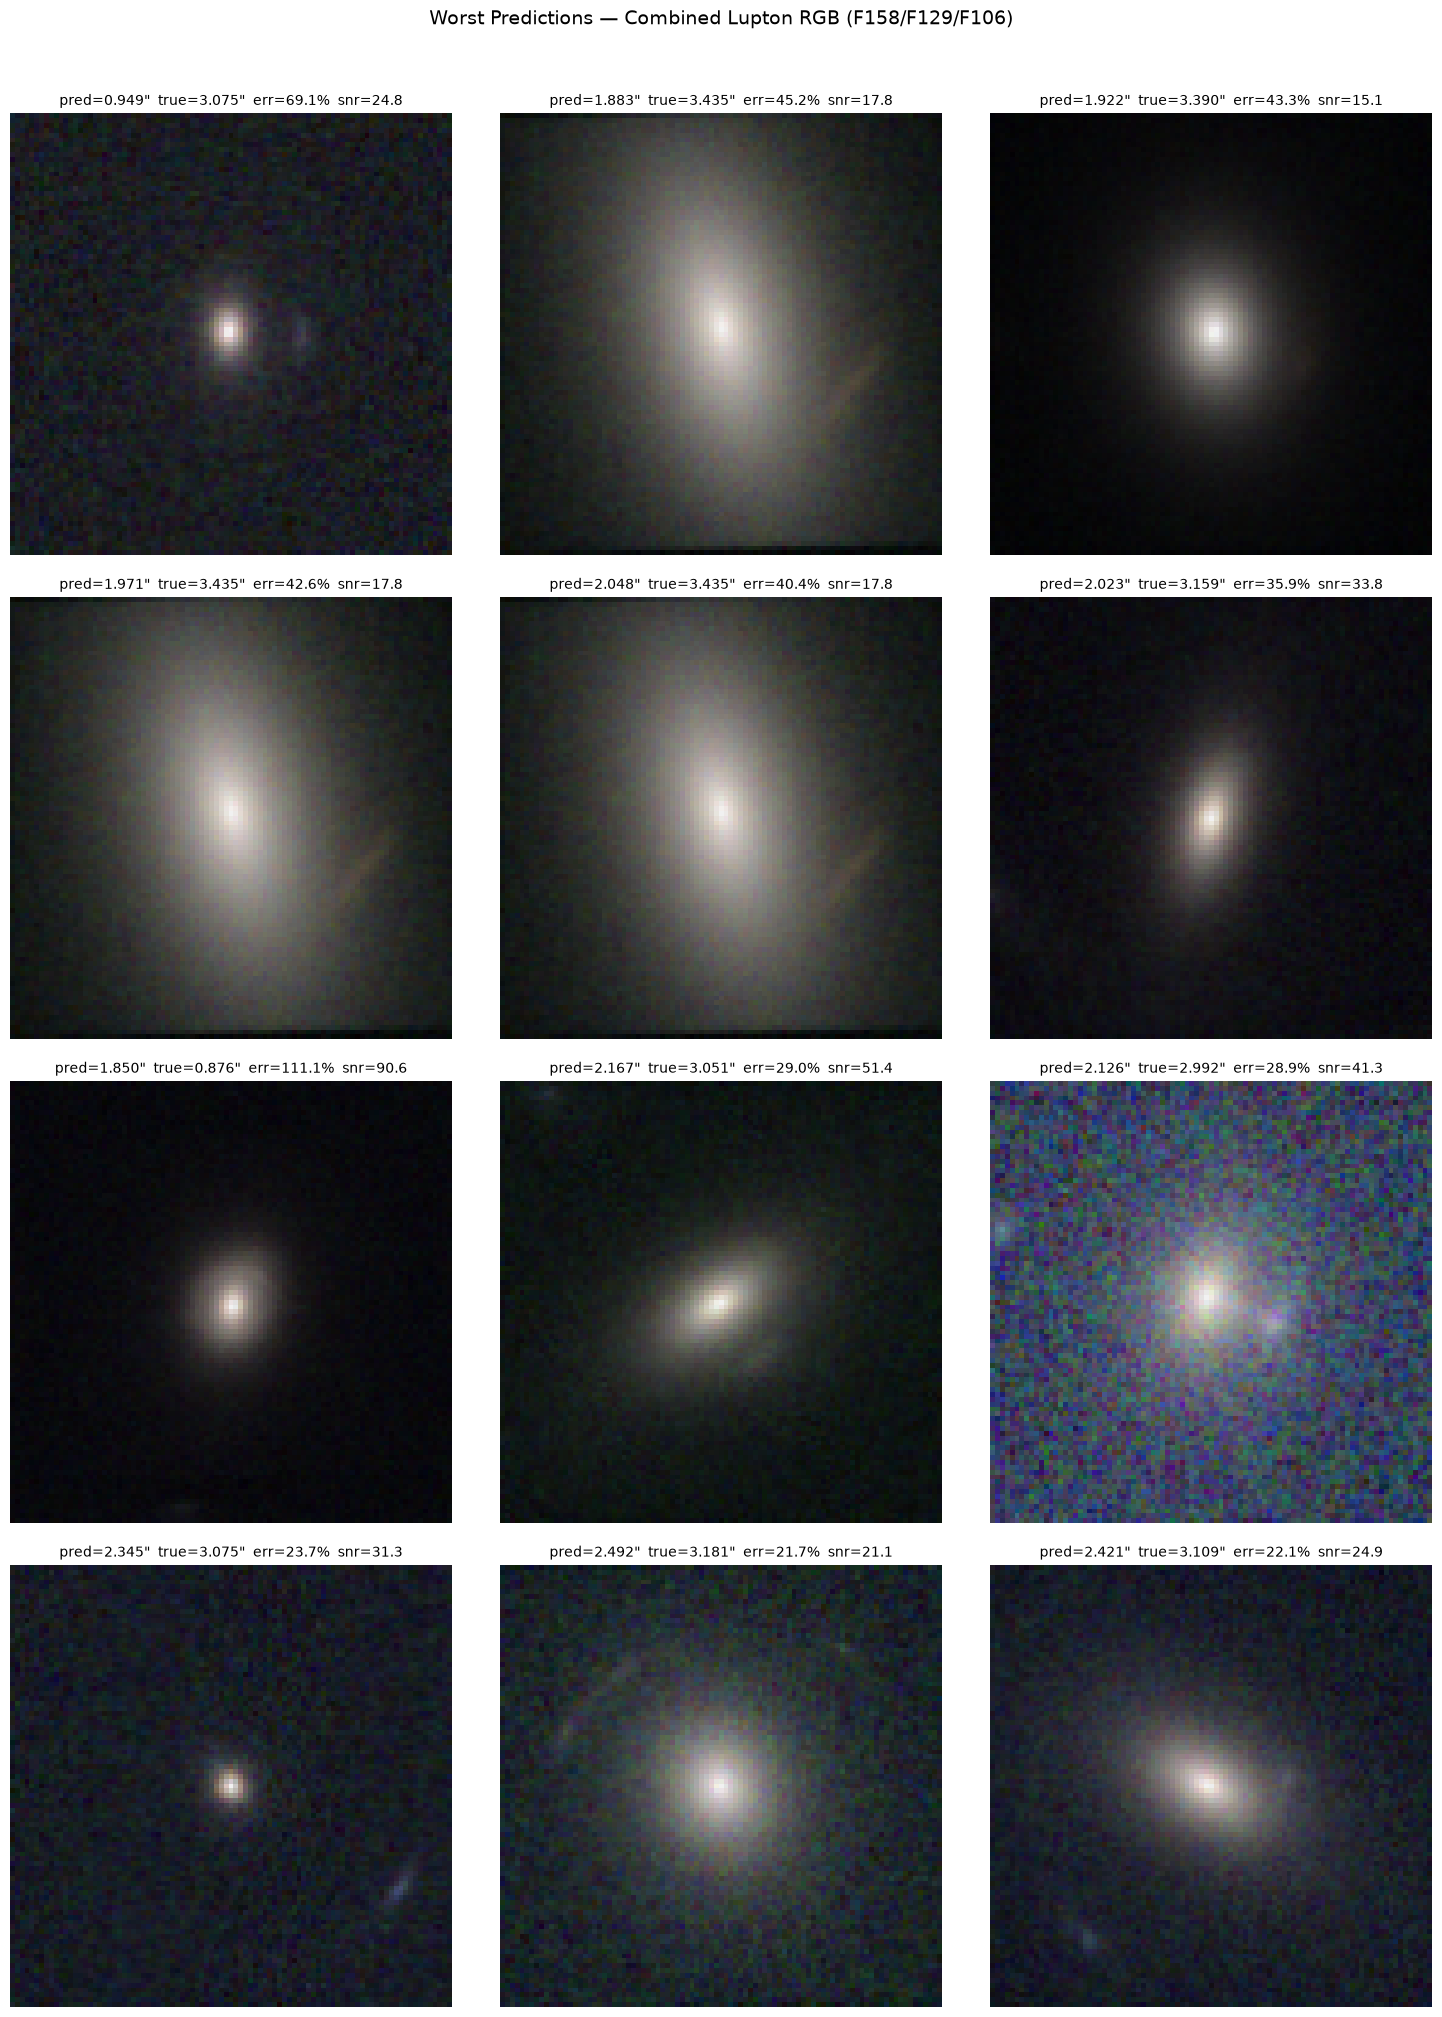

In [29]:
worst_df = get_worst_predictions(all_preds, all_labels, orig_indices_full, n_worst=25)
worst_df = attach_physical_properties(worst_df, labels, snr_values=snr_values)
print_worst_summary(worst_df, n_show=25)
plot_worst_images(worst_df, rgb_previews, n_show=12, cols=3, panel_size=5)


findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: F

Test set θ_e range: 0.137" to 3.591"
Quartile edges: [0.13692626 0.4457711  0.62956962 0.93747884 3.60127474]

── R² and Error Metrics by Einstein Radius Quartile ────────────────────
Bin                  Range (arcsec)            N     RMSE      MAE       R²
───────────────────────────────────────────────────────────────────────────
Q1 (smallest θ_e)    0.137–0.446            1450   0.0414   0.0324   0.7084
Q2                   0.446–0.630            1451   0.0432   0.0313   0.3318
Q3                   0.630–0.937            1449   0.0702   0.0464   0.3765
Q4 (largest θ_e)     0.937–3.601            1452   0.1759   0.1081   0.8894
───────────────────────────────────────────────────────────────────────────


findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: F

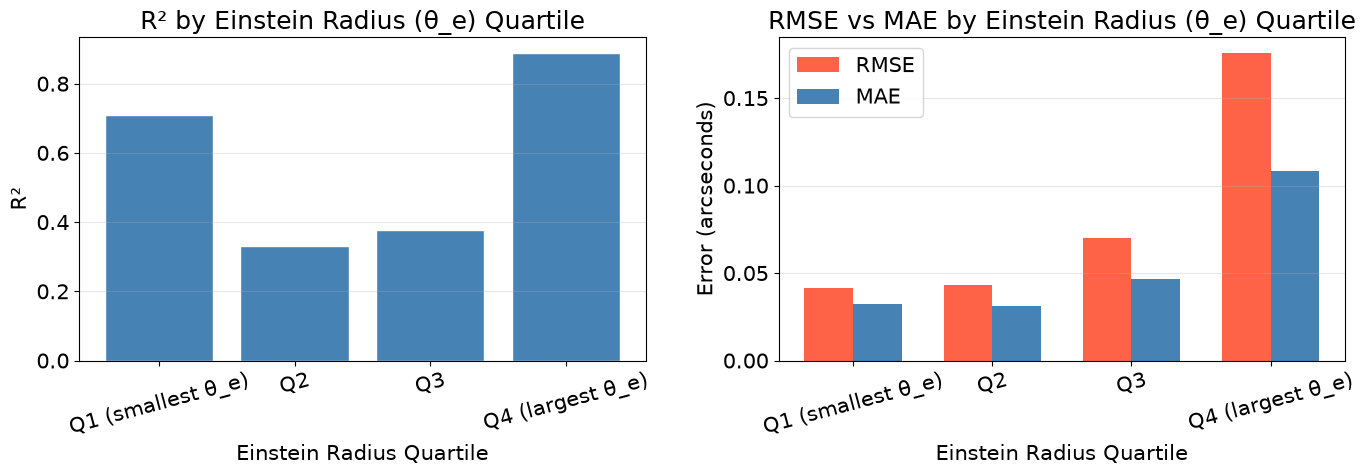

In [30]:
theta_e_bin_edges = np.percentile(all_labels, [0, 25, 50, 75, 100])
theta_e_bin_edges[-1] += 0.01
theta_e_bin_labels = ['Q1 (smallest θ_e)', 'Q2', 'Q3', 'Q4 (largest θ_e)']

print(f'Test set θ_e range: {all_labels.min():.3f}" to {all_labels.max():.3f}"')
print(f'Quartile edges: {theta_e_bin_edges}')

print('\n── R² and Error Metrics by Einstein Radius Quartile ────────────────────')
print(f'{"Bin":<20} {"Range (arcsec)":<20} {"N":>6} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('─' * 75)

bin_results = []
for i in range(len(theta_e_bin_edges) - 1):
    lo, hi = theta_e_bin_edges[i], theta_e_bin_edges[i + 1]
    mask = (all_labels >= lo) & (all_labels < hi)
    n_in_bin = mask.sum()

    if n_in_bin < 5:
        print(f'{theta_e_bin_labels[i]:<20} {"":<20} {n_in_bin:>6}    (too few samples)')
        continue

    bin_preds  = all_preds[mask]
    bin_truth  = all_labels[mask]

    bin_rmse = np.sqrt(np.mean((bin_preds - bin_truth) ** 2))
    bin_mae  = np.mean(np.abs(bin_preds - bin_truth))
    bin_r2   = r2_score(bin_truth, bin_preds)

    range_str = f'{lo:.3f}–{hi:.3f}'
    bin_results.append({
        'bin': theta_e_bin_labels[i], 'range': range_str, 'n': n_in_bin,
        'rmse': bin_rmse, 'mae': bin_mae, 'r2': bin_r2
    })

    print(f'{theta_e_bin_labels[i]:<20} {range_str:<20} {n_in_bin:>6} {bin_rmse:>8.4f} {bin_mae:>8.4f} {bin_r2:>8.4f}')

print('─' * 75)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_plotted = [r['bin']  for r in bin_results]
r2_plotted   = [r['r2']   for r in bin_results]
rmse_plotted = [r['rmse'] for r in bin_results]
mae_plotted  = [r['mae']  for r in bin_results]

axes[0].bar(bins_plotted, r2_plotted, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Einstein Radius Quartile')
axes[0].set_ylabel('R²')
axes[0].set_title('R² by Einstein Radius (θ_e) Quartile')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(alpha=0.3, axis='y')

x = np.arange(len(bins_plotted))
width = 0.35
axes[1].bar(x - width/2, rmse_plotted, width, label='RMSE', color='tomato')
axes[1].bar(x + width/2, mae_plotted,  width, label='MAE',  color='steelblue')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bins_plotted, rotation=15)
axes[1].set_xlabel('Einstein Radius Quartile')
axes[1].set_ylabel('Error (arcseconds)')
axes[1].set_title('RMSE vs MAE by Einstein Radius (θ_e) Quartile')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## Cell 19: Inspect Individual Predictions

findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: F

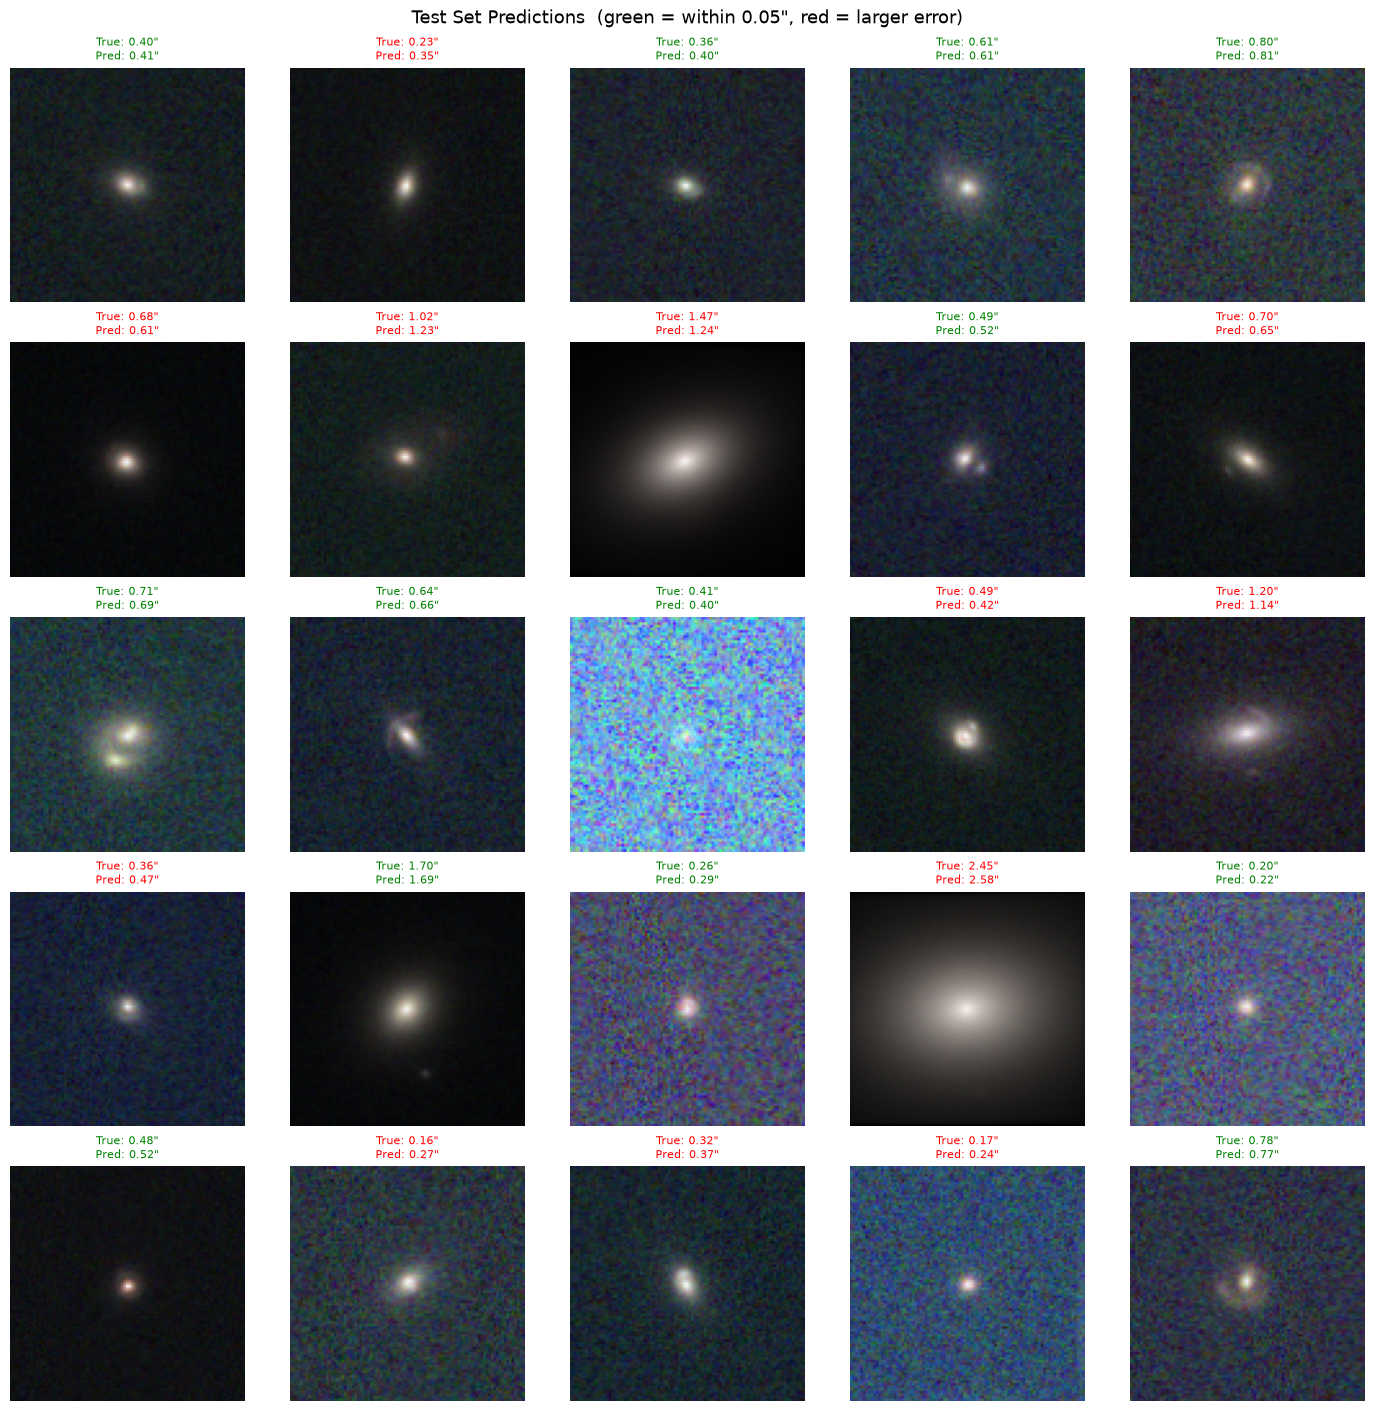

In [31]:
test_indices = test_set.indices
orig_indices = [idx // 8 for idx in test_indices[:25]]

fig, axes = plt.subplots(5, 5, figsize=(14, 14), constrained_layout=True)

for i, (orig_idx, pred, true) in enumerate(zip(orig_indices, all_preds[:25], all_labels[:25])):
    row, col = i // 5, i % 5
    axes[row, col].imshow(rgb_previews[orig_idx])
    axes[row, col].set_title(
        f'True: {true:.2f}"\nPred: {pred:.2f}"',
        fontsize=8,
        color='green' if abs(pred - true) < 0.05 else 'red'
    )
    axes[row, col].axis('off')

plt.suptitle('Test Set Predictions  (green = within 0.05", red = larger error)', fontsize=13)
plt.show()

In [32]:
THRESHOLD = 0.05

correct = np.abs(all_preds - all_labels) < THRESHOLD
pct_correct = 100 * np.mean(correct)

print(f'Correct (within {THRESHOLD}"): {correct.sum()} / {len(all_labels)}')
print(f'Percentage correct: {pct_correct:.2f}%')

Correct (within 0.05"): 3828 / 5802
Percentage correct: 65.98%


---
# Two-Stage Cascade: Classify, then Regress

This is the actual end-to-end pipeline: every test image goes through `clf_model` first. Only the images `clf_model` classifies as lenses get passed to `model` for a θ_e prediction. Images classified as nonlens never reach the regressor at all — they get `NaN` for `theta_e`.

This requires both training loops above (Cell 9 for the classifier, Cell 15 for the regressor) to have already been run, since it just loads whichever weights are saved to `best_clf_model.pt` and `best_model.pt`.


In [37]:
def run_two_stage_pipeline(images_tensor, clf_model, reg_model, device, threshold=0.5, batch_size=256):
    '''
    Stage 1: classify every image as lens/nonlens.
    Stage 2: only images classified as lenses get passed through the regressor.
    Returns predicted is_lens (0/1 per image) and predicted theta_e
    (NaN for images the classifier called nonlens — they never reach Stage 2).
    Processes in batches to avoid loading the whole test set onto the GPU at once
    (this previously crashed with a CUDA OutOfMemoryError on the full test set).
    '''
    clf_model.eval()
    reg_model.eval()

    all_is_lens = []
    all_theta_e = []

    with torch.no_grad():
        for start in range(0, len(images_tensor), batch_size):
            batch = images_tensor[start:start + batch_size].to(device)

            logits = clf_model(batch)
            probs = torch.sigmoid(logits)
            pred_is_lens = (probs > threshold).float()

            pred_theta_e = torch.full((len(batch),), float('nan'), device=device)
            lens_mask = pred_is_lens == 1
            if lens_mask.any():
                pred_theta_e[lens_mask] = reg_model(batch[lens_mask])

            all_is_lens.append(pred_is_lens.cpu().numpy())
            all_theta_e.append(pred_theta_e.cpu().numpy())

    return np.concatenate(all_is_lens), np.concatenate(all_theta_e)


In [38]:
test_indices_clf = test_set_clf.indices
cascade_images = images_clf_aug[test_indices_clf]
cascade_true_is_lens = labels_clf_aug[test_indices_clf]

# theta_e wasn't augmented, so map back to the pre-augmentation index
# (aug index // 8 = original images_clf index) to look up the true radius
orig_positions = [idx // 8 for idx in test_indices_clf]
cascade_true_theta_e = theta_e_clf[orig_positions]

cascade_tensor = torch.tensor(cascade_images, dtype=torch.float32)

pred_is_lens, pred_theta_e = run_two_stage_pipeline(cascade_tensor, clf_model, model, device)

print(f'Ran pipeline on {len(cascade_images)} test images')
print(f'Stage 1 classified {int(pred_is_lens.sum())} as lenses, '
      f'{len(pred_is_lens) - int(pred_is_lens.sum())} as nonlens')


Ran pipeline on 9716 test images
Stage 1 classified 5731 as lenses, 3985 as nonlens


In [39]:
acc  = accuracy_score(cascade_true_is_lens, pred_is_lens)
prec = precision_score(cascade_true_is_lens, pred_is_lens)
rec  = recall_score(cascade_true_is_lens, pred_is_lens)
f1   = f1_score(cascade_true_is_lens, pred_is_lens)
cm   = confusion_matrix(cascade_true_is_lens, pred_is_lens)

print('── Stage 1: Classifier Performance ───────────────────────')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1        : {f1:.4f}')
print('Confusion matrix (rows=true, cols=pred), order = [nonlens, lens]:')
print(cm)

true_lens_mask = cascade_true_is_lens == 1
pred_lens_mask = pred_is_lens == 1
true_positive_mask = true_lens_mask & pred_lens_mask

n_true_lens = int(true_lens_mask.sum())
print(f'\n── Pipeline Breakdown ──────────────────────────────')
print(f'True lenses in test set        : {n_true_lens}')
print(f'  → passed through to Stage 2  : {int(true_positive_mask.sum())} '
      f'({100*true_positive_mask.sum()/n_true_lens:.1f}%)')
print(f'  → missed at Stage 1          : {int((true_lens_mask & ~pred_lens_mask).sum())}')
print(f'Nonlens wrongly passed to Stage 2: {int(((~true_lens_mask) & pred_lens_mask).sum())}')

rmse = np.sqrt(np.mean((pred_theta_e[pred_lens_mask] - cascade_true_theta_e[pred_lens_mask]) ** 2))
mae  = np.mean(np.abs(pred_theta_e[pred_lens_mask] - cascade_true_theta_e[pred_lens_mask]))
r2   = r2_score(cascade_true_theta_e[pred_lens_mask], pred_theta_e[pred_lens_mask])

n_pred_lens = int(pred_lens_mask.sum())
n_false_pos = int((~true_lens_mask & pred_lens_mask).sum())
print(f'\n── Stage 2: Regression Performance (on all {n_pred_lens} images Stage 1 classified as lenses) ──')
print(f'  Of these, {n_false_pos} are classifier false positives '
      f'(true nonlens, scored against their deflector θ_e anyway)')
print(f'RMSE : {rmse:.4f} arcseconds')
print(f'MAE  : {mae:.4f} arcseconds')
print(f'R²   : {r2:.4f}')


── Stage 1: Classifier Performance ───────────────────────
Accuracy  : 0.9927
Precision : 0.9958
Recall    : 0.9918
F1        : 0.9938
Confusion matrix (rows=true, cols=pred), order = [nonlens, lens]:
[[3938   24]
 [  47 5707]]

── Pipeline Breakdown ──────────────────────────────
True lenses in test set        : 5754
  → passed through to Stage 2  : 5707 (99.2%)
  → missed at Stage 1          : 47
Nonlens wrongly passed to Stage 2: 24

── Stage 2: Regression Performance (on all 5731 images Stage 1 classified as lenses) ──
  Of these, 24 are classifier false positives (true nonlens, scored against their deflector θ_e anyway)
RMSE : 0.0693 arcseconds
MAE  : 0.0313 arcseconds
R²   : 0.9795


---
## Summary

### What this notebook does
| Step | Description |
|---|---|
| Data loading | Opens the `.h5` file, builds a lens+nonlens preview set and a lens+nonlens classifier dataset |
| Stage 1 | Trains `clf_model` (`ResNetCNN` + `BCEWithLogitsLoss`) to flag lens vs. nonlens |
| Stage 2 dataset | The ground-truth lens images from Cell 3 — kept separate from whatever the classifier flags |
| Stage 2 | Trains `model` (`ResNetCNN` + Huber loss) to predict θ_e on the ground-truth lens images |
| Cascade | Chains them: classify every test image first, regress only the ones flagged as lenses — false positives included, since the regressor never sees Stage 1's classification decision, only the image |
| Evaluation | Accuracy/precision/recall/F1 for Stage 1; RMSE/MAE/R² for Stage 2; end-to-end breakdown for the full pipeline |

### Architecture
`ResNetCNN` — a ResNet-18-inspired residual CNN (stem convolution, four stages of residual blocks with increasing channels, global average pooling, small FC head). Reused for both stages; only the loss function and output interpretation change. Optimizer: plain `Adam`, no warmup — convolutional inductive bias already stabilizes early training, so a warmup schedule isn't needed the way it is for a transformer.

### Run order
Run every cell top to bottom once. The two training loops (Stage 1's and Stage 2's) each take a while and only need to run once per session — after that, the saved `best_clf_model_6040.pt`/`best_model_6040.pt` weights are what the cascade cells at the end actually use.

### If Stage 1 recall is low
Real lenses are being lost before they ever reach the regressor — check the confusion matrix in Cell 10 and consider lowering the classification `threshold` in `run_two_stage_pipeline` below 0.5 to trade some precision for recall.
